# jax-hod basic examples

This notebook demonstrates the core functionality of `jax-hod`: defining an HOD model, inspecting its mean occupation functions, and populating a halo catalogue with mock galaxies.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxhod import Zheng07, populate, NFW, UniformSphere

## 1. The Zheng et al. (2007) HOD model

The 5-parameter model describes the mean number of central and satellite galaxies as a function of halo mass:

$$\langle N_\mathrm{cen}\rangle(M) = \frac{1}{2}\left[1 + \mathrm{erf}\!\left(\frac{\log_{10}M - \log_{10}M_\mathrm{min}}{\sigma_{\log M}}\right)\right]$$

$$\langle N_\mathrm{sat}\rangle(M) = \langle N_\mathrm{cen}\rangle(M)\left(\frac{M - M_0}{M_1}\right)^\alpha \quad (M > M_0)$$

In [2]:
model = Zheng07(
    log_Mmin=13.0,
    sigma_logM=0.5,
    log_M0=13.0,
    log_M1=14.0,
    alpha=1.0,
)
print(model)

Zheng07(log_Mmin=13.0, sigma_logM=0.5, log_M0=13.0, log_M1=14.0, alpha=1.0)


### Mean occupation functions

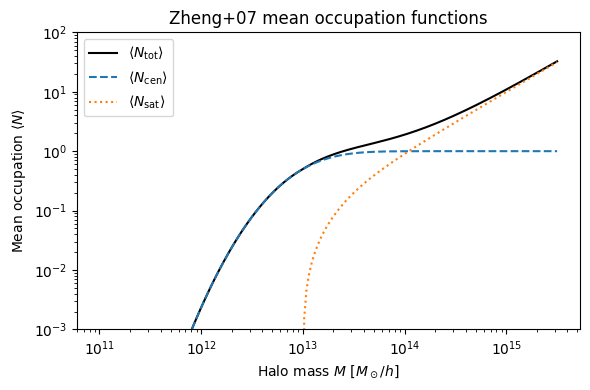

In [3]:
masses = jnp.logspace(11, 15.5, 200)

ncen = model.mean_ncen(masses)
nsat = model.mean_nsat(masses)
ntot = ncen + nsat

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(masses, ntot,  label=r'$\langle N_\mathrm{tot}\rangle$', color='k')
ax.loglog(masses, ncen,  label=r'$\langle N_\mathrm{cen}\rangle$', ls='--')
ax.loglog(masses, nsat,  label=r'$\langle N_\mathrm{sat}\rangle$', ls=':')
ax.set_xlabel(r'Halo mass $M$ [$M_\odot/h$]')
ax.set_ylabel(r'Mean occupation $\langle N \rangle$')
ax.set_ylim(1e-3, 1e2)
ax.legend()
ax.set_title('Zheng+07 mean occupation functions')
plt.tight_layout()
plt.show()

## 2. Populating a mock halo catalogue

We generate a simple random halo catalogue and run the HOD population. In practice you would load halo positions and masses from a simulation.

In [4]:
rng = jax.random.PRNGKey(42)
key_pos, key_mass, key_hod = jax.random.split(rng, 3)

n_halos   = 10_000
box_size  = 1000.0   # Mpc/h

halo_positions = jax.random.uniform(key_pos, (n_halos, 3), minval=0.0, maxval=box_size)
halo_masses    = 10 ** jax.random.uniform(key_mass, (n_halos,), minval=12.0, maxval=15.5)

# Virial radius: simple scaling R_vir ~ M^(1/3), normalised to 1 Mpc/h at 1e14 Msun/h
halo_radii = (halo_masses / 1e14) ** (1.0 / 3.0)

print(f'Number of halos : {n_halos:,}')
print(f'Mass range      : {halo_masses.min():.2e} – {halo_masses.max():.2e} Msun/h')

Number of halos : 10,000
Mass range      : 1.00e+12 – 3.16e+15 Msun/h


In [ ]:
result = populate(
    halo_positions,
    halo_masses,
    halo_radii,
    model,
    key_hod,
    max_satellites=50,
)

gal_positions  = result['positions']   # (N_gal, 3)
gal_is_central = result['is_central']  # (N_gal,) — True for centrals

n_cen = gal_is_central.sum()
n_sat = (~gal_is_central).sum()
print(f'Central galaxies  : {n_cen:,}')
print(f'Satellite galaxies: {n_sat:,}')
print(f'Total galaxies    : {n_cen + n_sat:,}')
print(f'Satellite fraction: {n_sat / (n_cen + n_sat):.2f}')

### Galaxy distribution in the box

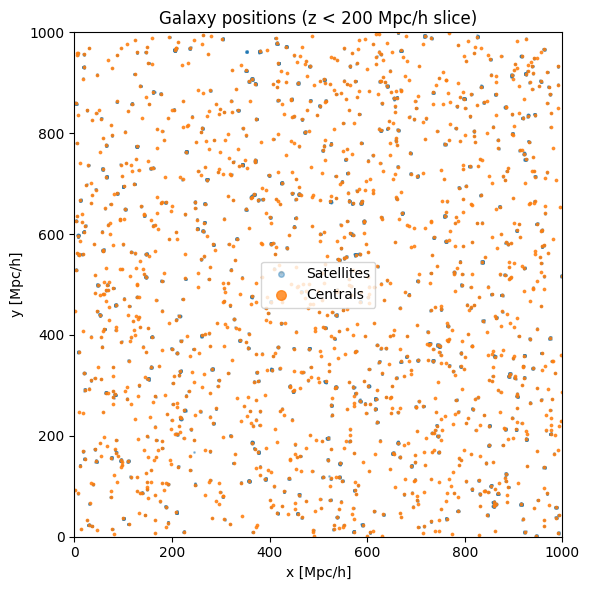

In [6]:
# Project along z-axis; show a 200 Mpc/h slice
z_slice = gal_positions[:, 2] < 200.0

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    gal_positions[z_slice & ~gal_is_central, 0],
    gal_positions[z_slice & ~gal_is_central, 1],
    s=1, alpha=0.4, label='Satellites', rasterized=True,
)
ax.scatter(
    gal_positions[z_slice & gal_is_central, 0],
    gal_positions[z_slice & gal_is_central, 1],
    s=3, alpha=0.8, label='Centrals', rasterized=True,
)
ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
ax.set_title(f'Galaxy positions (z < 200 Mpc/h slice)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 3. Galaxy number density vs. HOD parameters

Vary `log_Mmin` to see how it shifts the number density.

In [7]:
log_Mmin_values = [12.5, 13.0, 13.5]
colors = ['tab:blue', 'tab:orange', 'tab:green']
volume = box_size ** 3

for log_Mmin, color in zip(log_Mmin_values, colors):
    m = Zheng07(log_Mmin=log_Mmin, sigma_logM=0.5, log_M0=log_Mmin, log_M1=log_Mmin + 1, alpha=1.0)
    res = populate(halo_positions, halo_masses, halo_radii, m, key_hod, max_satellites=50)
    n_gal = int(np.array(res['mask']).sum())
    ng = n_gal / volume
    print(f'log_Mmin={log_Mmin:.1f}  →  N_gal={n_gal:,}  n_g={ng:.2e} (h/Mpc)^3')

log_Mmin=12.5  →  N_gal=112,088  n_g=1.12e-04 (h/Mpc)^3
log_Mmin=13.0  →  N_gal=45,681  n_g=4.57e-05 (h/Mpc)^3
log_Mmin=13.5  →  N_gal=17,131  n_g=1.71e-05 (h/Mpc)^3


## 4. JIT compilation

`populate` converts results to NumPy at the end, so it cannot itself be wrapped in `jax.jit`. For repeated calls inside a hot loop (e.g. MCMC), use the internal `_populate` which is fully JIT-compatible and returns padded JAX arrays.

In [ ]:
from jaxhod.populate import _populate

_populate_jit = jax.jit(
    lambda pos, m, r, k: _populate(pos, m, r, model, k, max_satellites=50)
)

# Warm-up (triggers compilation)
_ = _populate_jit(halo_positions, halo_masses, halo_radii, key_hod)
_['positions'].block_until_ready()

# Timed run
import time
t0 = time.perf_counter()
for _ in range(10):
    out = _populate_jit(halo_positions, halo_masses, halo_radii, key_hod)
    out['positions'].block_until_ready()
print(f'Mean time per call: {(time.perf_counter() - t0) / 10 * 1e3:.1f} ms  ({n_halos:,} halos)')

## 5. Satellite radial profiles: NFW vs uniform sphere

By default satellites are placed according to an NFW profile. Here we compare the radial distribution of satellites relative to their host halo centre for NFW (default, `concentration=5`) and `UniformSphere`.

In [ ]:
def satellite_distances(result, halo_positions, halo_radii, n_halos, max_sat):
    """Return satellite distances normalised by virial radius (valid satellites only).
    Uses the padded output of _populate to recover the halo assignment of each satellite.
    """
    sat_pos = np.array(result['positions'][n_halos:]).reshape(n_halos, max_sat, 3)
    sat_mask = np.array(result['mask'][n_halos:]).reshape(n_halos, max_sat)
    offsets = sat_pos - np.array(halo_positions)[:, None, :]
    dist = np.linalg.norm(offsets, axis=-1)
    rvir = np.array(halo_radii)[:, None] * np.ones((1, max_sat))
    return (dist / rvir)[sat_mask]


max_sat = 50
key_profile = jax.random.PRNGKey(99)

# Use _populate here to retain the halo-satellite assignment needed for r/r_vir
res_nfw = _populate(halo_positions, halo_masses, halo_radii, model, key_profile,
                    max_satellites=max_sat, profile=NFW(concentration=5.0))
res_uni = _populate(halo_positions, halo_masses, halo_radii, model, key_profile,
                    max_satellites=max_sat, profile=UniformSphere())

d_nfw = satellite_distances(res_nfw, halo_positions, halo_radii, n_halos, max_sat)
d_uni = satellite_distances(res_uni, halo_positions, halo_radii, n_halos, max_sat)

bins = np.linspace(0, 1, 40)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.hist(d_uni, bins=bins, density=True, alpha=0.6, label='UniformSphere')
ax.hist(d_nfw, bins=bins, density=True, alpha=0.6, label='NFW (c=5)')
ax.set_xlabel(r'$r\,/\,r_\mathrm{vir}$')
ax.set_ylabel('Probability density')
ax.set_title('Satellite radial distribution')
ax.legend()

ax = axes[1]
ax.plot(np.sort(d_uni), np.linspace(0, 1, len(d_uni)), label='UniformSphere')
ax.plot(np.sort(d_nfw), np.linspace(0, 1, len(d_nfw)), label='NFW (c=5)')
ax.set_xlabel(r'$r\,/\,r_\mathrm{vir}$')
ax.set_ylabel('CDF')
ax.set_title('Cumulative satellite radial distribution')
ax.legend()

plt.tight_layout()
plt.show()

print(f'NFW     — median r/r_vir: {np.median(d_nfw):.3f}')
print(f'Uniform — median r/r_vir: {np.median(d_uni):.3f}')

### Per-halo concentration

`NFW` also accepts a per-halo concentration array, so you can use a concentration-mass relation from your simulation.

Concentration range: 3.08 – 6.05


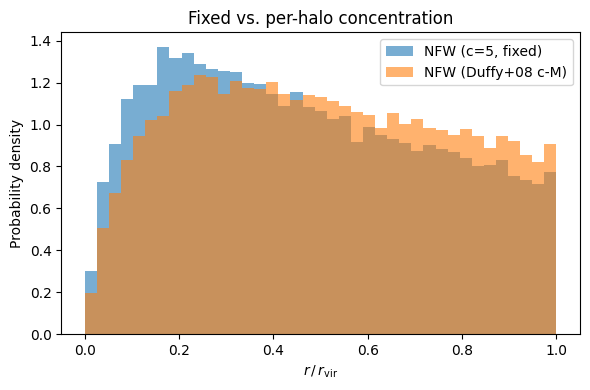

In [10]:
# Duffy et al. (2008) concentration-mass relation (simplified)
# c(M) = A * (M / M_pivot)^B,  A=5.71, B=-0.084, M_pivot=2e12 Msun/h
concentrations = 5.71 * (halo_masses / 2e12) ** (-0.084)
print(f'Concentration range: {concentrations.min():.2f} – {concentrations.max():.2f}')

res_cm = populate(halo_positions, halo_masses, halo_radii, model, key_profile,
                  max_satellites=max_sat, profile=NFW(concentration=concentrations))

d_cm = satellite_distances(res_cm, halo_positions, halo_radii, n_halos, max_sat)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(d_nfw, bins=bins, density=True, alpha=0.6, label='NFW (c=5, fixed)')
ax.hist(d_cm,  bins=bins, density=True, alpha=0.6, label='NFW (Duffy+08 c-M)')
ax.set_xlabel(r'$r\,/\,r_\mathrm{vir}$')
ax.set_ylabel('Probability density')
ax.set_title('Fixed vs. per-halo concentration')
ax.legend()
plt.tight_layout()
plt.show()